# IEEE-CIS Fraud Detection
### Supervised Fraud Classification (XGBoost & LightGBM)

**Dataset:** [IEEE-CIS Fraud Detection](https://www.kaggle.com/competitions/ieee-fraud-detection) (real, labeled e-commerce transactions)
**Task:** Binary classification — predict `isFraud`
**Models:** XGBoost, LightGBM (gradient-boosted trees), compared head-to-head
**Approach:** Since this dataset has real ground-truth fraud labels (unlike the earlier synthetic dataset, which had no labels and needed unsupervised anomaly detection), we use supervised classification — it makes far better use of the label and typically gives much stronger performance than Isolation Forest / Autoencoder anomaly scoring.



**Notebook structure:**
1. Load & merge training data
2. Target exploration
3. Memory optimization
4. Missing value analysis
5. Feature engineering
6. Exploratory data analysis
7. Time-based train/test split
8. Class imbalance handling
9. Train XGBoost
10. Train LightGBM
11. Model comparison
12. Feature importance
13. Threshold tuning & business rules (Approve / Verify / Block)
14. Save models
15. Inference on sample transactions
16. Score the test set (all 4 datasets used) & write submission.csv


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)

import xgboost as xgb
import lightgbm as lgb

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("XGBoost:", xgb.__version__)
print("LightGBM:", lgb.__version__)

NumPy: 1.24.3
Pandas: 2.1.4
XGBoost: 3.2.0
LightGBM: 4.7.0


In [2]:
np.random.seed(42)
print("Random seed set.")

Random seed set.


In [5]:
DATA_DIR = "."  # folder containing the extracted IEEE-CIS csv files

In [6]:
def reduce_mem_usage(df, verbose=True):
    """Downcast numeric columns to the smallest safe dtype to cut memory use."""
    start_mem = df.memory_usage().sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtype

        # only touch actual numeric dtypes (dtype.kind: i=int, u=uint, f=float)
        if col_type.kind in "iuf":
            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == "int":
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f"Memory usage: {start_mem:.1f} MB -> {end_mem:.1f} MB "
              f"({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)")
    return df


def load_csv_efficient(path, chunksize=100_000):
    """Read a large CSV in chunks, downcasting each chunk immediately.

    Reading the whole file at once lets pandas allocate everything at
    full-precision dtypes (float64 / object) before we ever get a chance
    to shrink it, which is what causes MemoryError on machines with
    limited RAM for a file this wide (394 columns). Downcasting chunk by
    chunk keeps peak memory far lower.
    """
    chunks = []
    for chunk in pd.read_csv(path, chunksize=chunksize):
        chunk = reduce_mem_usage(chunk, verbose=False)
        chunks.append(chunk)
    return pd.concat(chunks, ignore_index=True)


print("Memory-efficient CSV loader ready.")

Memory-efficient CSV loader ready.


In [7]:
train_transaction = load_csv_efficient(f"{DATA_DIR}/train_transaction.csv")
train_identity = load_csv_efficient(f"{DATA_DIR}/train_identity.csv")

print("train_transaction:", train_transaction.shape)
print("train_identity:", train_identity.shape)

train_transaction: (590540, 394)
train_identity: (144233, 41)


In [8]:
df = train_transaction.merge(train_identity, on="TransactionID", how="left")

del train_transaction, train_identity

print("Merged shape:", df.shape)
df.head()

Merged shape: (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.50%


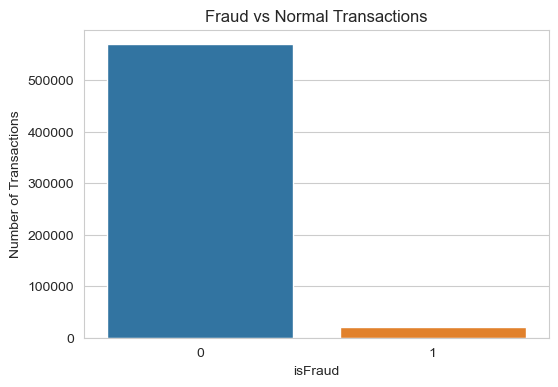

In [9]:
fraud_counts = df["isFraud"].value_counts()
fraud_rate = df["isFraud"].mean() * 100

print(fraud_counts)
print(f"\nFraud rate: {fraud_rate:.2f}%")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="isFraud")
plt.title("Fraud vs Normal Transactions")
plt.xlabel("isFraud")
plt.ylabel("Number of Transactions")
plt.show()

In [10]:
df = reduce_mem_usage(df)

Memory usage: 1044.7 MB -> 1044.7 MB (0.0% reduction)


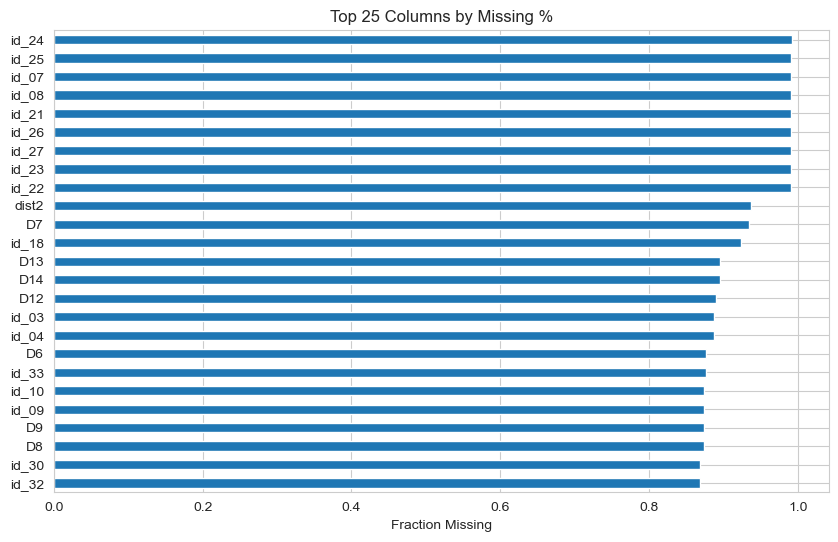

Columns with >90% missing: 12


In [11]:
missing_pct = df.isnull().mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
missing_pct.head(25).plot(kind="barh")
plt.title("Top 25 Columns by Missing %")
plt.xlabel("Fraction Missing")
plt.gca().invert_yaxis()
plt.show()

print(f"Columns with >90% missing: {(missing_pct > 0.9).sum()}")

In [12]:
MISSING_THRESHOLD = 0.9

high_missing_cols = missing_pct[missing_pct > MISSING_THRESHOLD].index.tolist()
df = df.drop(columns=high_missing_cols)

print(f"Dropped {len(high_missing_cols)} columns with >{MISSING_THRESHOLD*100:.0f}% missing values.")
print("Remaining shape:", df.shape)

Dropped 12 columns with >90% missing values.
Remaining shape: (590540, 422)


In [13]:
df["Transaction_hour"] = (df["TransactionDT"] / 3600) % 24
df["Transaction_day"] = (df["TransactionDT"] / (3600 * 24)) % 7
df["Transaction_day"] = df["Transaction_day"].astype(int)

df[["TransactionDT", "Transaction_hour", "Transaction_day"]].head()

,TransactionDT,Transaction_hour,Transaction_day
0,86400,0.000000,1
1,86401,0.000278,1
2,86469,0.019167,1
3,86499,0.027500,1
4,86506,0.029444,1


In [14]:
df["TransactionAmt_log"] = np.log1p(df["TransactionAmt"])

# The cents on a transaction amount can carry signal (e.g. always-round amounts)
df["TransactionAmt_decimal"] = (
    (df["TransactionAmt"] - df["TransactionAmt"].astype(int)) * 1000
).astype(int)

df[["TransactionAmt", "TransactionAmt_log", "TransactionAmt_decimal"]].head()

,TransactionAmt,TransactionAmt_log,TransactionAmt_decimal
0,68.5,4.241327,500
1,29.0,3.401197,0
2,59.0,4.094345,0
3,50.0,3.931826,0
4,50.0,3.931826,0


In [15]:
def email_provider(x):
    if pd.isna(x):
        return "missing"
    x = str(x)
    if "gmail" in x:
        return "google"
    if "yahoo" in x:
        return "yahoo"
    if any(k in x for k in ["hotmail", "outlook", "live", "msn"]):
        return "microsoft"
    if "aol" in x:
        return "aol"
    if any(k in x for k in ["icloud", "mac.com", "me.com"]):
        return "apple"
    return "other"


df["P_email_provider"] = df["P_emaildomain"].apply(email_provider)
df["R_email_provider"] = df["R_emaildomain"].apply(email_provider)
df["email_domain_match"] = (df["P_emaildomain"] == df["R_emaildomain"]).astype(int)

df[["P_emaildomain", "P_email_provider", "R_emaildomain", "R_email_provider", "email_domain_match"]].head()

,P_emaildomain,P_email_provider,R_emaildomain,R_email_provider,email_domain_match
0,NaN,missing,NaN,missing,0
1,gmail.com,google,NaN,missing,0
2,outlook.com,microsoft,NaN,missing,0
3,yahoo.com,yahoo,NaN,missing,0
4,gmail.com,google,NaN,missing,0


In [16]:
# Frequency encoding for high-cardinality identifiers: how common is this
# card / address? Rare cards or addresses are often riskier.
for col in ["card1", "card2", "addr1"]:
    freq = df[col].value_counts(dropna=False)
    df[f"{col}_freq"] = df[col].map(freq)

df[["card1", "card1_freq", "card2", "card2_freq", "addr1", "addr1_freq"]].head()

,card1,card1_freq,card2,card2_freq,addr1,addr1_freq
0,13926,43,NaN,8933,315.0,23078
1,2755,683,404.0,3056,325.0,42751
2,4663,1108,490.0,38145,330.0,26287
3,18132,4209,567.0,6137,476.0,9478
4,4497,18,514.0,14541,420.0,3581


In [17]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
print(f"Categorical columns to encode ({len(categorical_cols)}):")
print(categorical_cols)

label_encoders = {}
for col in categorical_cols:
    df[col] = df[col].astype(str)
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("\nAll columns numeric now:", df.select_dtypes(include=["object", "string"]).shape[1] == 0)

Categorical columns to encode (31):
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo', 'P_email_provider', 'R_email_provider']

All columns numeric now: True


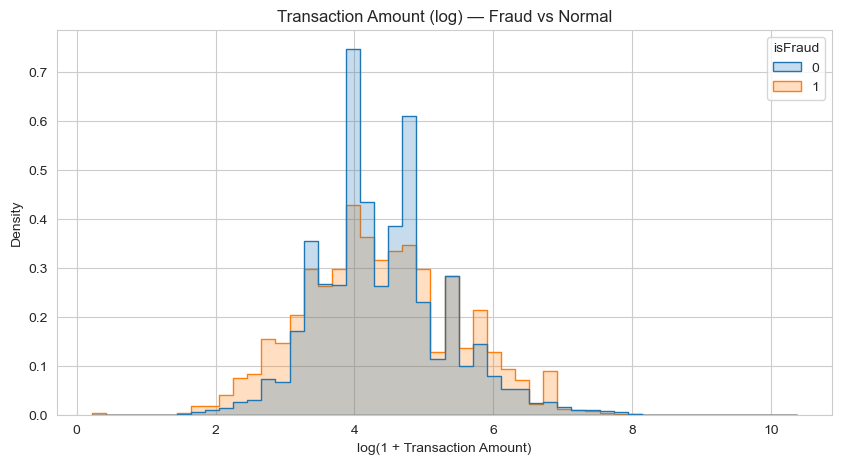

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="TransactionAmt_log", hue="isFraud", bins=50,
             stat="density", common_norm=False, element="step")
plt.title("Transaction Amount (log) — Fraud vs Normal")
plt.xlabel("log(1 + Transaction Amount)")
plt.show()

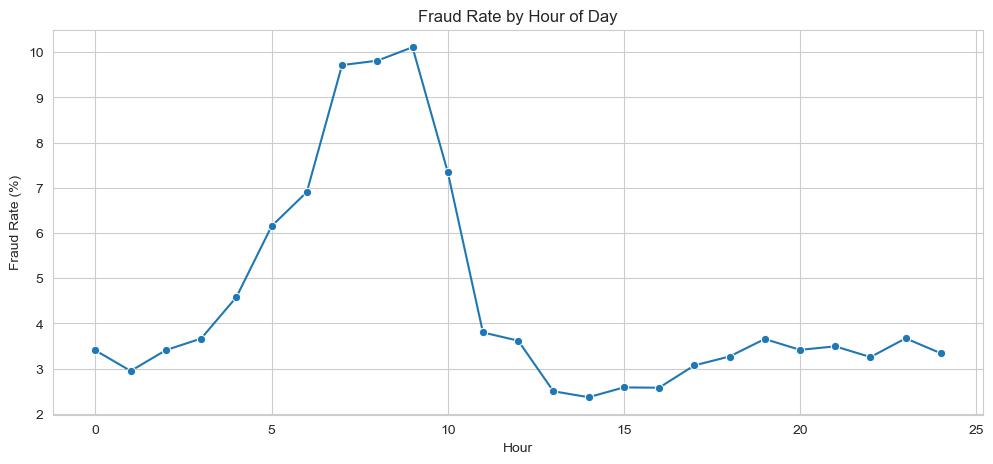

In [19]:
hourly_fraud_rate = (
    df.groupby(df["Transaction_hour"].round().astype(int))["isFraud"]
    .mean()
    .mul(100)
    .reset_index(name="fraud_rate")
    .rename(columns={"Transaction_hour": "hour"})
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_fraud_rate, x="hour", y="fraud_rate", marker="o")
plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.show()

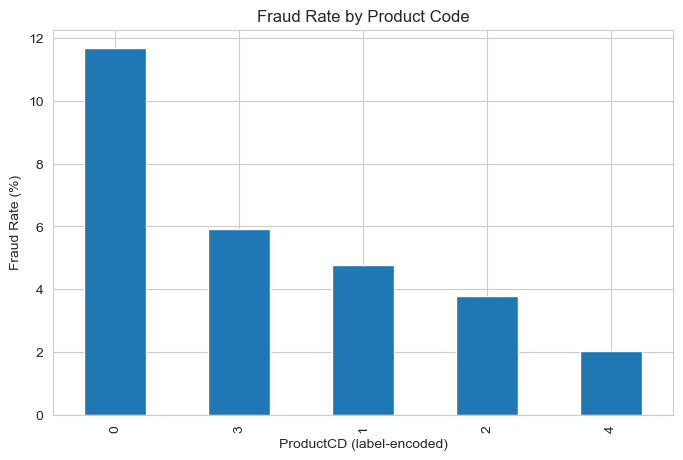

In [20]:
plt.figure(figsize=(8, 5))
product_fraud_rate = df.groupby("ProductCD")["isFraud"].mean().mul(100).sort_values(ascending=False)
product_fraud_rate.plot(kind="bar")
plt.title("Fraud Rate by Product Code")
plt.ylabel("Fraud Rate (%)")
plt.xlabel("ProductCD (label-encoded)")
plt.show()

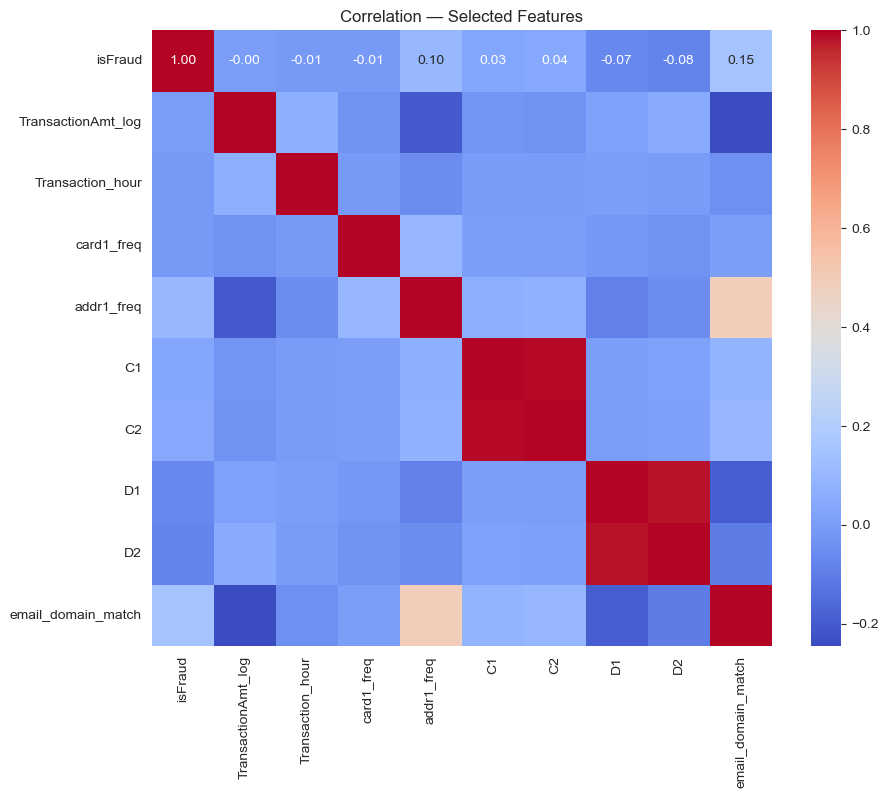

In [21]:
numeric_preview = [
    "isFraud", "TransactionAmt_log", "Transaction_hour", "card1_freq",
    "addr1_freq", "C1", "C2", "D1", "D2", "email_domain_match",
]
numeric_preview = [c for c in numeric_preview if c in df.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_preview].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation — Selected Features")
plt.show()

In [22]:
df = df.sort_values("TransactionDT").reset_index(drop=True)

drop_cols = ["TransactionID", "isFraud", "TransactionDT"]
features = [c for c in df.columns if c not in drop_cols]

split_idx = int(len(df) * 0.8)

X_train = df.iloc[:split_idx][features]
X_test = df.iloc[split_idx:][features]
y_train = df.iloc[:split_idx]["isFraud"]
y_test = df.iloc[split_idx:]["isFraud"]

print("Train:", X_train.shape, "| Fraud rate:", f"{y_train.mean()*100:.2f}%")
print("Test :", X_test.shape, "| Fraud rate:", f"{y_test.mean()*100:.2f}%")
print("Number of features:", len(features))

Train: (472432, 429) | Fraud rate: 3.51%
Test : (118108, 429) | Fraud rate: 3.44%
Number of features: 429


In [23]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")
print("(i.e. each fraud example is weighted this many times a normal example)")

scale_pos_weight: 27.46
(i.e. each fraud example is weighted this many times a normal example)


In [24]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    tree_method="hist",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)

[0]	validation_0-aucpr:0.34947
[50]	validation_0-aucpr:0.46682
[100]	validation_0-aucpr:0.48972
[150]	validation_0-aucpr:0.50330
[200]	validation_0-aucpr:0.51348
[250]	validation_0-aucpr:0.52286
[300]	validation_0-aucpr:0.52727
[350]	validation_0-aucpr:0.53326
[400]	validation_0-aucpr:0.53798
[450]	validation_0-aucpr:0.54307
[499]	validation_0-aucpr:0.54617


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

In [25]:
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_proba >= 0.5).astype(int)

xgb_roc_auc = roc_auc_score(y_test, xgb_proba)
xgb_pr_auc = average_precision_score(y_test, xgb_proba)

print(f"ROC-AUC: {xgb_roc_auc:.4f}")
print(f"PR-AUC : {xgb_pr_auc:.4f}\n")
print(classification_report(y_test, xgb_pred, target_names=["Normal", "Fraud"]))

ROC-AUC: 0.9123
PR-AUC : 0.5463

              precision    recall  f1-score   support

      Normal       0.99      0.95      0.97    114044
       Fraud       0.31      0.68      0.42      4064

    accuracy                           0.94    118108
   macro avg       0.65      0.81      0.69    118108
weighted avg       0.96      0.94      0.95    118108



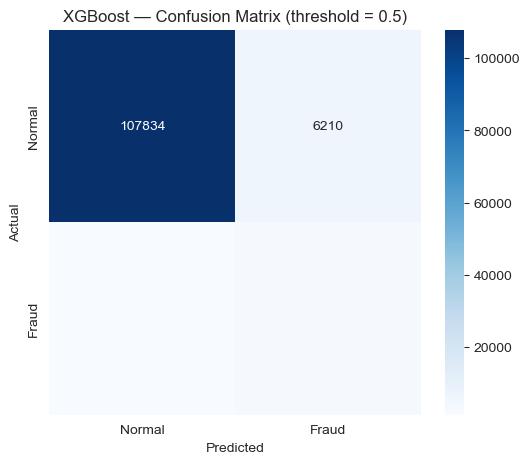

In [26]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Fraud"], yticklabels=["Normal", "Fraud"])
plt.title("XGBoost — Confusion Matrix (threshold = 0.5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
import gc

# Force plain, contiguous float32 arrays — avoids passing pandas-internal
# (possibly non-contiguous or extension-dtype) memory straight into
# LightGBM's C backend, which is the most common cause of Windows crashes.
# float32 (not float64): LightGBM converts labels/features to float32
# internally regardless, so float64 here only doubles memory for no benefit.
X_train_lgb = np.ascontiguousarray(X_train.to_numpy(dtype=np.float32))
X_test_lgb = np.ascontiguousarray(X_test.to_numpy(dtype=np.float32))
y_train_lgb = np.ascontiguousarray(y_train.to_numpy(dtype=np.float32))
y_test_lgb = np.ascontiguousarray(y_test.to_numpy(dtype=np.float32))

# Free the pandas copies now that we have plain arrays — X_train/X_test
# aren't needed again below (XGBoost already trained on them earlier).
del X_train, X_test
gc.collect()

lgb_model = None
lgb_proba = None

try:
    lgb_model = lgb.LGBMClassifier(
        n_estimators=500,
        max_depth=7,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=1,  # start single-threaded; raise once you confirm training runs cleanly
        verbose=-1,
    )

    lgb_model.fit(
        X_train_lgb, y_train_lgb,
        eval_set=[(X_test_lgb, y_test_lgb)],
        eval_metric="average_precision",
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )
except Exception as e:
    print(f"LightGBM training failed ({type(e).__name__}: {e})")
    print("This is almost always a broken LightGBM install on Windows, not a data problem.")
    print("Fix: install the Visual C++ Redistributable (https://aka.ms/vs/17/release/vc_redist.x64.exe),")
    print("then run: pip uninstall lightgbm -y && pip install lightgbm --no-cache-dir --force-reinstall")
    print("Continuing with XGBoost only.")
    lgb_model = None

LightGBM training failed (OSError: exception: access violation reading 0x0000000000000000)
This is almost always a broken LightGBM install on Windows, not a data problem.
Fix: install the Visual C++ Redistributable (https://aka.ms/vs/17/release/vc_redist.x64.exe),
then run: pip uninstall lightgbm -y && pip install lightgbm --no-cache-dir --force-reinstall
Continuing with XGBoost only.


In [28]:
if lgb_model is not None:
    lgb_proba = lgb_model.predict_proba(X_test_lgb)[:, 1]
    lgb_pred = (lgb_proba >= 0.5).astype(int)

    lgb_roc_auc = roc_auc_score(y_test, lgb_proba)
    lgb_pr_auc = average_precision_score(y_test, lgb_proba)

    print(f"ROC-AUC: {lgb_roc_auc:.4f}")
    print(f"PR-AUC : {lgb_pr_auc:.4f}\n")
    print(classification_report(y_test, lgb_pred, target_names=["Normal", "Fraud"]))
else:
    lgb_roc_auc = None
    lgb_pr_auc = None
    print("Skipping LightGBM evaluation — training failed above.")

Skipping LightGBM evaluation — training failed above.


In [29]:
if lgb_model is not None:
    cm = confusion_matrix(y_test, lgb_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=["Normal", "Fraud"], yticklabels=["Normal", "Fraud"])
    plt.title("LightGBM — Confusion Matrix (threshold = 0.5)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
else:
    print("Skipping LightGBM confusion matrix — training failed above.")

Skipping LightGBM confusion matrix — training failed above.


In [30]:
comparison_rows = [{"Model": "XGBoost", "ROC-AUC": xgb_roc_auc, "PR-AUC": xgb_pr_auc}]
if lgb_model is not None:
    comparison_rows.append({"Model": "LightGBM", "ROC-AUC": lgb_roc_auc, "PR-AUC": lgb_pr_auc})

comparison = pd.DataFrame(comparison_rows)
comparison

,Model,ROC-AUC,PR-AUC
0,XGBoost,0.912334,0.546324


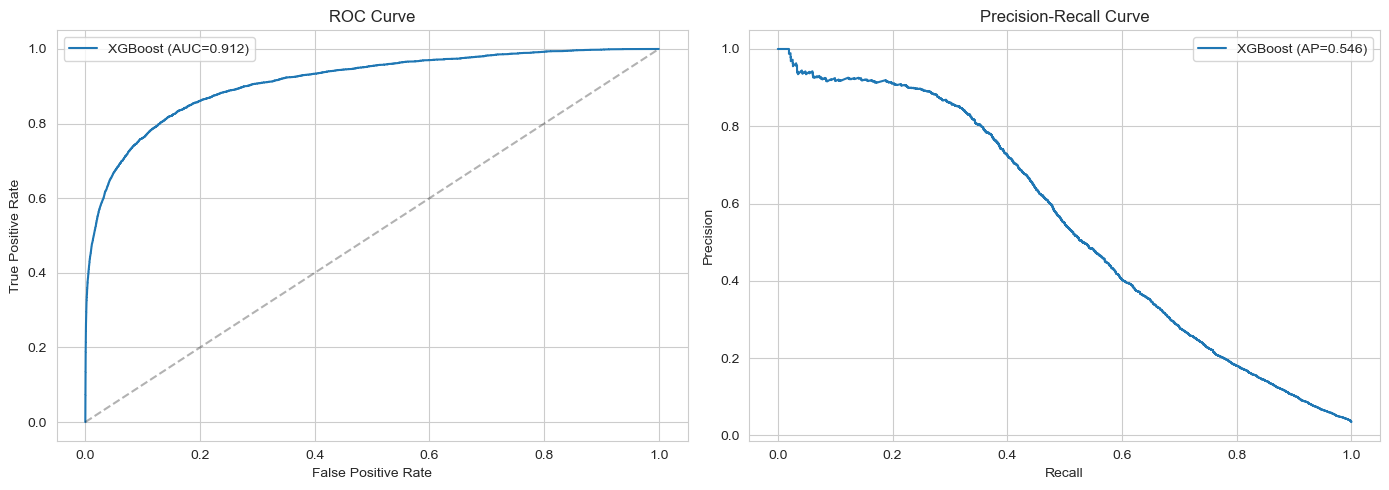

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_to_plot = [("XGBoost", xgb_proba)]
if lgb_model is not None:
    models_to_plot.append(("LightGBM", lgb_proba))

for name, proba in models_to_plot:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")

    precision, recall, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(recall, precision, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

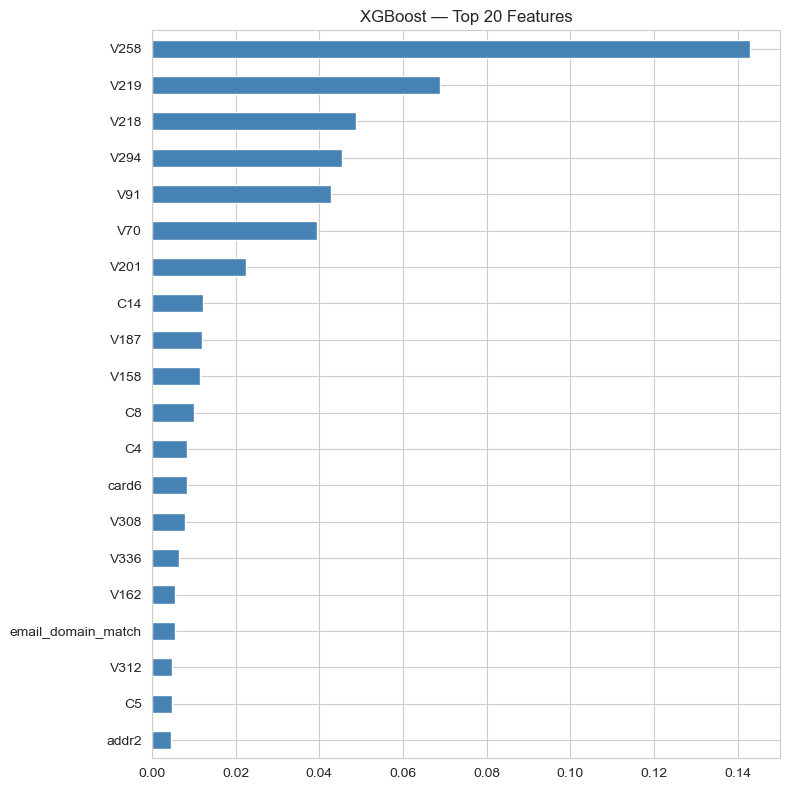

In [32]:
if lgb_model is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
else:
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    axes = [ax]

xgb_importance = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False).head(20)
xgb_importance.iloc[::-1].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("XGBoost — Top 20 Features")

if lgb_model is not None:
    lgb_importance = pd.Series(lgb_model.feature_importances_, index=features).sort_values(ascending=False).head(20)
    lgb_importance.iloc[::-1].plot(kind="barh", ax=axes[1], color="seagreen")
    axes[1].set_title("LightGBM — Top 20 Features")

plt.tight_layout()
plt.show()

Using XGBoost for thresholding.


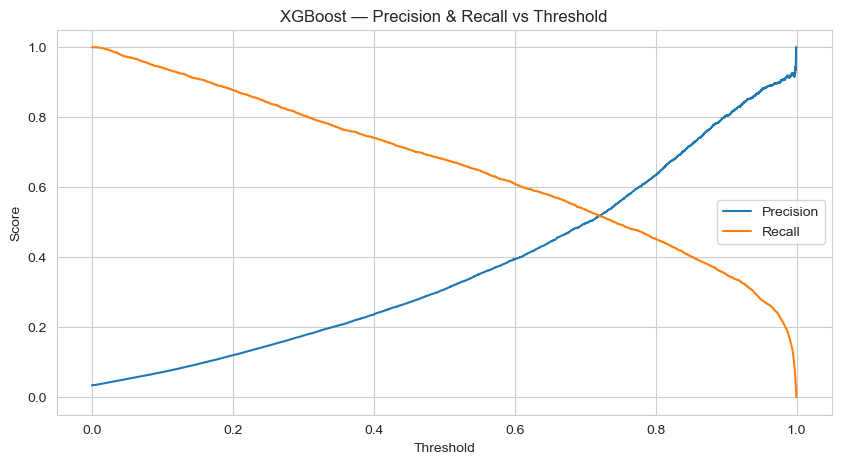

In [33]:
if lgb_model is not None and lgb_pr_auc >= xgb_pr_auc:
    best_model_name = "LightGBM"
    best_proba = lgb_proba
else:
    best_model_name = "XGBoost"
    best_proba = xgb_proba

print(f"Using {best_model_name} for thresholding.")

precision, recall, thresholds = precision_recall_curve(y_test, best_proba)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title(f"{best_model_name} — Precision & Recall vs Threshold")
plt.legend()
plt.show()

In [34]:
results = pd.DataFrame({"is_fraud": y_test.values, "risk_score": best_proba})

# LOW/HIGH thresholds chosen from the percentiles of predicted risk among
# transactions the model believes are normal — mirrors the approach used
# for the earlier anomaly-score-based notebook, just applied to a
# probability instead of a reconstruction error / isolation score.
normal_scores = results.loc[results["is_fraud"] == 0, "risk_score"]
low_threshold = np.percentile(normal_scores, 95)
high_threshold = np.percentile(normal_scores, 99.5)

print(f"LOW threshold:  {low_threshold:.4f}")
print(f"HIGH threshold: {high_threshold:.4f}")


def classify_risk(score):
    if score < low_threshold:
        return "LOW"
    elif score < high_threshold:
        return "MEDIUM"
    else:
        return "HIGH"


def transaction_action(risk_level):
    return {"LOW": "APPROVE", "MEDIUM": "VERIFY", "HIGH": "BLOCK"}[risk_level]


results["risk_level"] = results["risk_score"].apply(classify_risk)
results["action"] = results["risk_level"].apply(transaction_action)

results["risk_level"].value_counts()

LOW threshold:  0.5170
HIGH threshold: 0.8598


risk_level
LOW       109684
MEDIUM      6255
HIGH        2169
Name: count, dtype: int64

In [35]:
action_fraud_rate = (
    results.groupby("action")["is_fraud"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "fraud_rate"})
)
action_fraud_rate["fraud_rate"] *= 100
action_fraud_rate

,count,fraud_rate
action,,
APPROVE,109684,1.224427
BLOCK,2169,73.674504
VERIFY,6255,17.953637


In [36]:
total_fraud = (results["is_fraud"] == 1).sum()
fraud_blocked = ((results["is_fraud"] == 1) & (results["action"] == "BLOCK")).sum()
fraud_verified = ((results["is_fraud"] == 1) & (results["action"] == "VERIFY")).sum()
fraud_approved = ((results["is_fraud"] == 1) & (results["action"] == "APPROVE")).sum()

print("Total fraud in test set:", total_fraud)
print(f"Fraud blocked:   {fraud_blocked} ({fraud_blocked/total_fraud*100:.1f}%)")
print(f"Fraud verified:  {fraud_verified} ({fraud_verified/total_fraud*100:.1f}%)")
print(f"Fraud approved:  {fraud_approved} ({fraud_approved/total_fraud*100:.1f}%)  <- missed fraud")

Total fraud in test set: 4064
Fraud blocked:   1598 (39.3%)
Fraud verified:  1123 (27.6%)
Fraud approved:  1343 (33.0%)  <- missed fraud


In [37]:
import joblib

joblib.dump(xgb_model, "xgb_fraud_model.pkl")
if lgb_model is not None:
    joblib.dump(lgb_model, "lgb_fraud_model.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")
joblib.dump(features, "feature_list.pkl")
joblib.dump({"low": low_threshold, "high": high_threshold}, "risk_thresholds.pkl")

print("Models, encoders, feature list, and thresholds saved.")

Models, encoders, feature list, and thresholds saved.


In [38]:
sample = df.iloc[split_idx:split_idx + 10].copy()
sample_X = sample[features]

sample_proba = xgb_model.predict_proba(sample_X)[:, 1]
sample["risk_score"] = sample_proba
sample["risk_level"] = sample["risk_score"].apply(classify_risk)
sample["action"] = sample["risk_level"].apply(transaction_action)

sample[["TransactionID", "TransactionAmt", "isFraud", "risk_score", "risk_level", "action"]]

,TransactionID,TransactionAmt,isFraud,risk_score,risk_level,action
472432,3459432,33.261002,1,0.299653,LOW,APPROVE
472433,3459433,52.811001,0,0.027722,LOW,APPROVE
472434,3459434,136.955994,0,0.844494,MEDIUM,VERIFY
472435,3459435,136.955994,0,0.899356,HIGH,BLOCK
472436,3459436,25.000000,0,0.016599,LOW,APPROVE
472437,3459437,23.362000,0,0.069670,LOW,APPROVE
472438,3459438,326.290009,0,0.115539,LOW,APPROVE
472439,3459439,34.000000,0,0.192342,LOW,APPROVE
472440,3459440,50.000000,0,0.165113,LOW,APPROVE
472441,3459441,67.949997,0,0.182663,LOW,APPROVE


## 16. Score the Kaggle Test Set

The zip file actually contains **four** real datasets, not two: `train_transaction` / `train_identity` (used above, labeled) and `test_transaction` / `test_identity` (unlabeled — this is what the competition is actually scored against). Plus `sample_submission.csv`, which just shows the expected output format.

This section applies the *exact same* preprocessing (same label encoders, same dropped columns, same engineered features) that was fit on the training data, scores every row of the test set, and writes a submission file in the Kaggle-expected format (`TransactionID`, `isFraud` probability).

In [39]:
test_transaction = load_csv_efficient(f"{DATA_DIR}/test_transaction.csv")
test_identity = load_csv_efficient(f"{DATA_DIR}/test_identity.csv")

test_df = test_transaction.merge(test_identity, on="TransactionID", how="left")
del test_transaction, test_identity

print("test_df:", test_df.shape)
test_df.head()

test_df: (506691, 433)


,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663549,18403224,31.950001,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.000000,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.000000,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.950012,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.949997,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
test_df = reduce_mem_usage(test_df)
test_df = test_df.drop(columns=[c for c in high_missing_cols if c in test_df.columns])

test_df["Transaction_hour"] = (test_df["TransactionDT"] / 3600) % 24
test_df["Transaction_day"] = ((test_df["TransactionDT"] / (3600 * 24)) % 7).astype(int)
test_df["TransactionAmt_log"] = np.log1p(test_df["TransactionAmt"])
test_df["TransactionAmt_decimal"] = (
    (test_df["TransactionAmt"] - test_df["TransactionAmt"].astype(int)) * 1000
).astype(int)
test_df["P_email_provider"] = test_df["P_emaildomain"].apply(email_provider)
test_df["R_email_provider"] = test_df["R_emaildomain"].apply(email_provider)
test_df["email_domain_match"] = (test_df["P_emaildomain"] == test_df["R_emaildomain"]).astype(int)

for col in ["card1", "card2", "addr1"]:
    freq = test_df[col].value_counts(dropna=False)
    test_df[f"{col}_freq"] = test_df[col].map(freq)

for col, le in label_encoders.items():
    if col in test_df.columns:
        test_df[col] = test_df[col].astype(str)
        # unseen categories at inference time -> map to a fixed "known" class
        # rather than crashing the encoder
        test_df[col] = test_df[col].map(lambda x: x if x in le.classes_ else le.classes_[0])
        test_df[col] = le.transform(test_df[col])

# some columns can theoretically be absent in test vs train (or vice versa) -
# align to the exact training feature list, filling anything missing with NaN
missing_features = [f for f in features if f not in test_df.columns]
for f in missing_features:
    test_df[f] = np.nan

print(f"{len(missing_features)} feature(s) missing from test set, filled with NaN.")
print("Aligned test feature matrix:", test_df[features].shape)

Memory usage: 895.9 MB -> 895.9 MB (0.0% reduction)
28 feature(s) missing from test set, filled with NaN.
Aligned test feature matrix: (506691, 429)


In [41]:
# Blend both models for the final submission if both are available — this
# generally scores a bit better than either model alone, since their errors
# aren't perfectly correlated. Falls back to XGBoost only if LightGBM failed.
xgb_test_proba = xgb_model.predict_proba(test_df[features])[:, 1]

if lgb_model is not None:
    lgb_test_proba = lgb_model.predict_proba(
        np.ascontiguousarray(test_df[features].to_numpy(dtype=np.float32))
    )[:, 1]
    test_proba = 0.5 * xgb_test_proba + 0.5 * lgb_test_proba
    print("Using blended XGBoost + LightGBM predictions.")
else:
    test_proba = xgb_test_proba
    print("Using XGBoost-only predictions (LightGBM unavailable).")

submission = pd.DataFrame({
    "TransactionID": test_df["TransactionID"],
    "isFraud": test_proba,
})

submission.to_csv("submission.csv", index=False)
print("Saved submission.csv:", submission.shape)
submission.head()

Using XGBoost-only predictions (LightGBM unavailable).
Saved submission.csv: (506691, 2)


,TransactionID,isFraud
0,3663549,0.009058
1,3663550,0.057876
2,3663551,0.007797
3,3663552,0.041244
4,3663553,0.028069


sample_submission shape: (506691, 2)
our submission shape:    (506691, 2)
All our TransactionIDs are valid: True


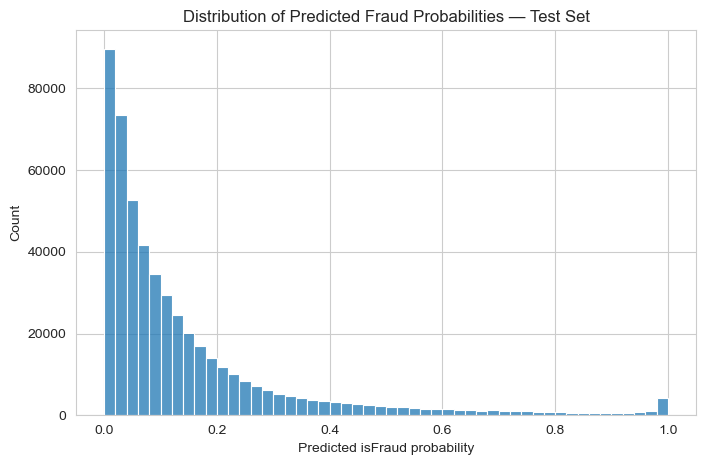

In [43]:
# Sanity check against the expected format
sample_submission = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

print("sample_submission shape:", sample_submission.shape)
print("our submission shape:   ", submission.shape)
print(
    "All our TransactionIDs are valid:",
    submission["TransactionID"].isin(sample_submission["TransactionID"]).all(),
)

plt.figure(figsize=(8, 5))
sns.histplot(submission["isFraud"], bins=50)
plt.title("Distribution of Predicted Fraud Probabilities — Test Set")
plt.xlabel("Predicted isFraud probability")
plt.show()